# Gram-Type Classification (Radial vs Strip vs Collapsed)

### Method
1. Load `host_type_all_preds.csv` and `metadata.csv`
2. Join on `proteinID`
3. Mean-pool protein scores to phage level (NaN-aware)
4. NaN handling: drop columns >50% NaN; impute with training medians
5. Split: 0 = test, 1–4 = train
6. Build one envelope per gram type per method
7. Evaluate and compare all three methods

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import time
import warnings
warnings.filterwarnings('ignore')

# np.random.seed(13)

### Loading the Data

- `host_type_all_preds.csv`: one row per protein, 40 function-specific gram-type score columns
- `metadata.csv`: one row per protein — `accession` (phage ID), `host_type`, `split`

In [2]:
SCORES_PATH   = "../Data/host_type_all_preds.csv"
METADATA_PATH = "../Data/metadata.csv"

print("Loading scores...")
t0 = time.time()
scores_df = pd.read_csv(SCORES_PATH, index_col="proteinID")
print(f"  scores shape : {scores_df.shape}  ({time.time()-t0:.1f}s)")

print("Loading metadata...")
t0 = time.time()
meta_df = pd.read_csv(METADATA_PATH, index_col="proteinID")
print(f"  metadata shape : {meta_df.shape}  ({time.time()-t0:.1f}s)")

meta_df = meta_df[["accession", "host_type", "split"]]

Loading scores...
  scores shape : (1853074, 40)  (2.7s)
Loading metadata...
  metadata shape : (1853074, 8)  (2.2s)


In [36]:
# Print the first 5 rows of scores_df
print("--- First 5 rows of Scores ---")
print(scores_df.head())

# Print the first 5 rows of meta_df
print("\n--- First 5 rows of Metadata ---")
print(meta_df.head())

--- First 5 rows of Scores ---
                host_type_lysin  host_type_endolysin  host_type_val  \
proteinID                                                             
AB002632_00001              NaN                  NaN            NaN   
AB002632_00002              NaN                  NaN            NaN   
AB002632_00003              NaN                  NaN            NaN   
AB002632_00004              NaN                  NaN            NaN   
AB002632_00005              NaN                  NaN            NaN   

                host_type_capsid  host_type_baseplate  \
proteinID                                               
AB002632_00001               NaN                  NaN   
AB002632_00002               NaN                  NaN   
AB002632_00003          0.029791                  NaN   
AB002632_00004               NaN                  NaN   
AB002632_00005          0.008570                  NaN   

                host_type_tail_appendage  host_type_tail_sheath  \
prot

### Joining the Scores and Metadata

In [3]:
combined = scores_df.join(meta_df, how="inner")
score_cols = [c for c in scores_df.columns if c.startswith("host_type_")]

print(f"Combined shape: {combined.shape}")
print(f"Score columns : {len(score_cols)}")
print("\nGram-type distribution (protein level):")
print(combined["host_type"].value_counts())
print("\nSplit distribution (0=test, 1–4=train):")
print(combined["split"].value_counts().sort_index())

Combined shape: (1853074, 43)
Score columns : 40

Gram-type distribution (protein level):
host_type
gram-neg    1151735
gram-pos     699623
unknown        1716
Name: count, dtype: int64

Split distribution (0=test, 1–4=train):
split
0    408069
1    313252
2    373117
3    371171
4    387465
Name: count, dtype: int64


### Mean-Pool Proteins → Phage Level Scores

For each phage and each function column, take the mean score across all annotated proteins

- NaN means the model was not applicable — not zero evidence.  

In [4]:
t0 = time.time()

phage_scores = combined.groupby("accession")[score_cols].mean()   # NaN-aware
phage_meta = combined.groupby("accession")[["host_type", "split"]].first()
phage_df = phage_scores.join(phage_meta)

print(f"  Phage-level shape: {phage_df.shape}  ({time.time()-t0:.1f}s)")
print("\nGram-type distribution (phage level):")
print(phage_df["host_type"].value_counts())
print("\nSplit distribution (phage level):")
print(phage_df["split"].value_counts().sort_index())

  Phage-level shape: (18474, 42)  (0.4s)

Gram-type distribution (phage level):
host_type
gram-neg    10735
gram-pos     7708
unknown        31
Name: count, dtype: int64

Split distribution (phage level):
split
0    4433
1    3173
2    3646
3    3588
4    3634
Name: count, dtype: int64


### NaN Analysis and Column Filtering

Drop columns where >50% of phages have NaN — these carry almost no signal.

In [5]:
nan_rates = phage_df[score_cols].isna().mean().sort_values(ascending=False)

print(f"NaN rate per column (top 10):")
print(nan_rates.head(10).to_string())

NAN_THRESHOLD = 0.50
valid_cols = nan_rates[nan_rates <= NAN_THRESHOLD].index.tolist()
dropped = nan_rates[nan_rates  > NAN_THRESHOLD].index.tolist()

print(f"\nColumns kept   : {len(valid_cols)} / {len(score_cols)}")
print(f"Columns dropped: {len(dropped)}")
if dropped:
    print(f"  Dropped: {dropped}")

K = len(valid_cols)
print(f"\nFinal K (dimensions) = {K}")

NaN rate per column (top 10):
host_type_sir2                         0.958320
host_type_lysis_inhibitor              0.893255
host_type_toxin                        0.795821
host_type_ejection                     0.767078
host_type_super_infection              0.744181
host_type_transcriptional_activator    0.740500
host_type_tail_sheath                  0.721176
host_type_replication_initiation       0.720418
host_type_reductase                    0.637869
host_type_annealing                    0.550936

Columns kept   : 27 / 40
Columns dropped: 13
  Dropped: ['host_type_sir2', 'host_type_lysis_inhibitor', 'host_type_toxin', 'host_type_ejection', 'host_type_super_infection', 'host_type_transcriptional_activator', 'host_type_tail_sheath', 'host_type_replication_initiation', 'host_type_reductase', 'host_type_annealing', 'host_type_spanin', 'host_type_baseplate', 'host_type_val']

Final K (dimensions) = 27


### Train / Test Split and Median Imputation

NaN means the model was not applicable — filling with zero would distort the envelope.  
We impute with **training-set medians only** (no data leakage), capped at 0.5 if median > 0.6.

The **Collapsed (1D) method** also uses this same imputed K-dim matrix as input —  it then collapses to a scalar *after* imputation, so NaN handling is consistent across all three methods.

In [6]:
# Train / Test Split 
train_df = phage_df[phage_df["split"] != 0].copy()
test_df = phage_df[phage_df["split"] == 0].copy()

train_df = train_df[train_df["host_type"].isin(["gram-neg", "gram-pos"])]
test_df = test_df[test_df["host_type"].isin(["gram-neg", "gram-pos"])]

print(f"Train phages : {len(train_df)}")
print(f"Test  phages : {len(test_df)}")

# Missingness Signal (before imputation)
train_df['nan_count'] = train_df[valid_cols].isna().sum(axis=1)
test_df['nan_count']  = test_df[valid_cols].isna().sum(axis=1)

# Median Imputation with Safety Cap 
train_medians = train_df[valid_cols].median()
safe_impute_values = train_medians.copy()
safe_impute_values[safe_impute_values > 0.6] = 0.5

train_df[valid_cols] = train_df[valid_cols].fillna(safe_impute_values)
test_df [valid_cols] = test_df [valid_cols].fillna(safe_impute_values)
train_df[valid_cols] = train_df[valid_cols].fillna(0.5)
test_df [valid_cols] = test_df [valid_cols].fillna(0.5)

print(f"\nResidual NaNs after imputation — train: {train_df[valid_cols].isna().sum().sum()}")
print(f"Residual NaNs after imputation — test : {test_df[valid_cols].isna().sum().sum()}")

# Extract K-dim score matrices
train_gramneg = train_df[train_df["host_type"] == "gram-neg"][valid_cols].values
train_grampos = train_df[train_df["host_type"] == "gram-pos"][valid_cols].values

test_scores = test_df[valid_cols].values
test_labels = test_df["host_type"].values

print(f"\nTraining infectors:")
print(f"  gram-neg : {train_gramneg.shape}")
print(f"  gram-pos : {train_grampos.shape}")

Train phages : 14021
Test  phages : 4422

Residual NaNs after imputation — train: 0
Residual NaNs after imputation — test : 0

Training infectors:
  gram-neg : (7924, 27)
  gram-pos : (6097, 27)


### Collapsed (1D) Scalar

After imputation, we further collapse each phage's K-dim vector to a single scalar by taking the row-wise mean. This is the input for the 1D conformal method.

In [7]:
# Collapse K-dim → scalar (row mean, no NaNs remain after imputation)
train_gramneg_1d = train_gramneg.mean(axis=1, keepdims=True)   # (N, 1)
train_grampos_1d = train_grampos.mean(axis=1, keepdims=True)   # (N, 1)
test_scores_1d = test_scores.mean(axis=1, keepdims=True)     # (N_test, 1)

print(f"Collapsed scalar shapes:")
print(f"  train gram-neg : {train_gramneg_1d.shape}")
print(f"  train gram-pos : {train_grampos_1d.shape}")
print(f"  test           : {test_scores_1d.shape}")
print(f"\nScalar score ranges:")
print(f"  gram-neg train: [{train_gramneg_1d.min():.3f}, {train_gramneg_1d.max():.3f}]")
print(f"  gram-pos train: [{train_grampos_1d.min():.3f}, {train_grampos_1d.max():.3f}]")

Collapsed scalar shapes:
  train gram-neg : (7924, 1)
  train gram-pos : (6097, 1)
  test           : (4422, 1)

Scalar score ranges:
  gram-neg train: [0.014, 0.831]
  gram-pos train: [0.059, 0.978]


### Envelope Methods

All three methods share the same two-stage calibration (S1 → shape, S2 → scale).

In [8]:
def split_data(scores, split_ratio=0.5):
    """Randomly split scores into S1 (shape discovery) and S2 (size scaling)."""
    n = len(scores)
    idx = np.random.permutation(n)
    cut = int(n * split_ratio)
    return scores[idx[:cut]], scores[idx[cut:]]

#### Method 1 — Radial (K-dim)
M random directions on positive unit sphere. Local radius threshold per sector.

In [9]:
def sample_positive_sphere(M, K):
    """Sample M directions on the positive orthant of S^{K-1}."""
    V = np.abs(np.random.randn(M, K))
    norms = np.linalg.norm(V, axis=1, keepdims=True)
    return V / (norms + 1e-12)


In [10]:
def radial_shape_discovery(S1, alpha, M, delta_deg=15):
    """For each of M directions, compute local (1-alpha) radius quantile."""
    K = S1.shape[1]
    U = sample_positive_sphere(M, K)
    mags = np.linalg.norm(S1, axis=1)
    dirs = S1 / (mags[:, None] + 1e-12)
    cos_thresh = np.cos(np.radians(delta_deg))
    q_tilde = np.zeros(M)
    for m in range(M):
        sims = dirs @ U[m]
        mask = sims >= cos_thresh
        if mask.sum() < 5:
            q_tilde[m] = np.quantile(mags, 1 - alpha)
        else:
            q_tilde[m] = np.quantile(mags[mask], 1 - alpha)
    return U, q_tilde


In [11]:
def radial_size_scaling(S2, U, q_tilde, alpha):
    """Find t_hat giving (1-alpha) coverage on S2."""
    boundary = U * q_tilde[:, None]
    ratios = S2[:, None, :] / (boundary[None, :, :] + 1e-12)
    tau_scores = ratios.max(axis=2).min(axis=1)
    n2 = len(tau_scores)
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    return np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]


In [12]:
def radial_is_in_region(scores, envelope):
    """True if score vector is inside the scaled radial envelope."""
    U, q_tilde, t_hat = envelope["U"], envelope["q_tilde"], envelope["t_hat"]
    boundary = U * (q_tilde * t_hat)[:, None]
    return np.any(np.all(scores[:, None, :] <= boundary[None, :, :], axis=2), axis=1)

def radial_build_envelope(infection_scores, alpha, M=200, delta_deg=30):
    """Full two-stage calibration for the radial method."""
    S1, S2 = split_data(infection_scores)
    U, q_tilde = radial_shape_discovery(S1, alpha, M, delta_deg)
    t_hat = radial_size_scaling(S2, U, q_tilde, alpha)
    return {"U": U, "q_tilde": q_tilde, "t_hat": t_hat, "method": "radial"}


#### Method 2 — Strip (K-dim)
M equal-width bins per dimension. Quantile threshold for each (j, i≠j) pair.

In [13]:
def strip_shape_discovery(S1, alpha, M):
    """For each (j, bin m), compute (1-alpha) quantile of all other dims i."""
    N1, K = S1.shape
    bin_edges = np.zeros((K, M + 1))
    for j in range(K):
        bin_edges[j] = np.linspace(S1[:, j].min(), S1[:, j].max(), M + 1)
    limits = np.zeros((K, K, M))
    for j in range(K):
        for m in range(M):
            lo, hi   = bin_edges[j, m], bin_edges[j, m + 1]
            in_strip = (S1[:, j] >= lo) & (S1[:, j] < hi)
            for i in range(K):
                if i == j: continue
                if in_strip.sum() < 3:
                    limits[j, i, m] = np.quantile(S1[:, i], 1 - alpha)
                else:
                    limits[j, i, m] = np.quantile(S1[in_strip, i], 1 - alpha)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            for m in range(M - 2, -1, -1):
                limits[j, i, m] = max(limits[j, i, m], limits[j, i, m + 1])
    return bin_edges, limits


In [14]:
def get_bin_indices(scores, bin_edges):
    """For each point and dimension, find which bin it falls in."""
    N, K = scores.shape
    M = bin_edges.shape[1] - 1
    indices = np.zeros((N, K), dtype=int)
    for j in range(K):
        raw = np.digitize(scores[:, j], bin_edges[j]) - 1
        indices[:, j] = np.clip(raw, 0, M - 1)
    return indices


In [15]:
def strip_size_scaling(S2, bin_edges, limits, alpha):
    """Find t_hat for the strip envelope."""
    N2, K = S2.shape
    bin_idx = get_bin_indices(S2, bin_edges)
    ratios = np.zeros((N2, K, K))
    for j in range(K):
        for i in range(K):
            if i == j: continue
            lims = limits[j, i, bin_idx[:, j]]
            ratios[:, j, i] = S2[:, i] / (lims + 1e-12)
    tau_scores = ratios.max(axis=(1, 2))
    n2 = N2
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    return np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]


In [16]:
def strip_is_in_region(scores, envelope):
    """True if score vector is inside the scaled strip envelope."""
    bin_edges, limits, t_hat = envelope["bin_edges"], envelope["limits"], envelope["t_hat"]
    N, K = scores.shape
    bin_idx = get_bin_indices(scores, bin_edges)
    scaled_limits = limits * t_hat
    inside = np.ones(N, dtype=bool)
    for j in range(K):
        for i in range(K):
            if i == j: continue
            inside &= (scores[:, i] <= scaled_limits[j, i, bin_idx[:, j]])
    return inside

def strip_build_envelope(infection_scores, alpha, M=20):
    """Full two-stage calibration for the strip method."""
    S1, S2 = split_data(infection_scores)
    bin_edges, limits = strip_shape_discovery(S1, alpha, M)
    t_hat = strip_size_scaling(S2, bin_edges, limits, alpha)
    return {"bin_edges": bin_edges, "limits": limits, "t_hat": t_hat, "method": "strip"}


#### Method 3 — Collapsed 1D

The scalar lives on [0, 1]. The conformal envelope is simply the interval [0, t̂]  where t̂ is the (1−α) quantile of the S2 calibration scalars. 

In [17]:
def collapsed_build_envelope(infection_scores_1d, alpha):
    """
    1D conformal envelope: interval [0, t_hat].
    S1 is used for shape (just the quantile threshold directly).
    S2 is used for size scaling to find t_hat.
    infection_scores_1d: (N, 1) array of scalar scores.
    """
    S1, S2 = split_data(infection_scores_1d)
    # Shape: the threshold is the (1-alpha) quantile of S1 scalars
    q_tilde = np.quantile(S1, 1 - alpha)
    # Size scaling: tau(s) = s / q_tilde; t_hat = (1-alpha) quantile of tau scores on S2
    tau_scores = (S2 / (q_tilde + 1e-12)).ravel()
    n2 = len(tau_scores)
    idx = int(np.ceil((n2 + 1) * (1 - alpha))) - 1
    t_hat = np.sort(tau_scores)[np.clip(idx, 0, n2 - 1)]
    return {"q_tilde": q_tilde, "t_hat": t_hat, "method": "collapsed"}


In [18]:
def collapsed_is_in_region(scores_1d, envelope):
    """True if scalar score is inside the 1D envelope [0, t_hat * q_tilde]."""
    threshold = envelope["q_tilde"] * envelope["t_hat"]
    return (scores_1d.ravel() <= threshold)

In [19]:
def is_in_region(scores, envelope):
    if envelope["method"] == "radial":
        return radial_is_in_region(scores, envelope)
    elif envelope["method"] == "strip":
        return strip_is_in_region(scores, envelope)
    else:
        return collapsed_is_in_region(scores, envelope)

In [20]:
def predict_gram_type(test_scores, envelopes):
    """
    For each test phage, check its score against both gram-type envelopes.
    Handles both K-dim (radial/strip) and 1D (collapsed) automatically.
    """
    in_gramneg = is_in_region(test_scores, envelopes["gram-neg"])
    in_grampos = is_in_region(test_scores, envelopes["gram-pos"])
    results = []
    for i in range(len(in_gramneg)):
        pred_set = []
        if in_gramneg[i]: pred_set.append("gram-neg")
        if in_grampos[i]: pred_set.append("gram-pos")
        results.append({"in_gramneg": bool(in_gramneg[i]),
                        "in_grampos": bool(in_grampos[i]),
                        "prediction_set": pred_set})
    return results


### Building the Envelopes on Training Data

In [21]:
alpha = 0.1   # target coverage = 1 - alpha = 0.90

print("Building radial envelopes (K-dim)...")
t0 = time.time()
radial_envelopes = {
    "gram-neg": radial_build_envelope(train_gramneg, alpha, M=200, delta_deg=30),
    "gram-pos": radial_build_envelope(train_grampos, alpha, M=200, delta_deg=30),
     }
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  t_hat (gram-neg) = {radial_envelopes['gram-neg']['t_hat']:.4f}")
print(f"  t_hat (gram-pos) = {radial_envelopes['gram-pos']['t_hat']:.4f}")

print("\nBuilding strip envelopes (K-dim)...")
t0 = time.time()
strip_envelopes = {
    "gram-neg": strip_build_envelope(train_gramneg, alpha, M=20),
    "gram-pos": strip_build_envelope(train_grampos, alpha, M=20),
    }
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  t_hat (gram-neg) = {strip_envelopes['gram-neg']['t_hat']:.4f}")
print(f"  t_hat (gram-pos) = {strip_envelopes['gram-pos']['t_hat']:.4f}")

print("\nBuilding collapsed 1D envelopes...")
t0 = time.time()
collapsed_envelopes = {
    "gram-neg": collapsed_build_envelope(train_gramneg_1d, alpha),
    "gram-pos": collapsed_build_envelope(train_grampos_1d, alpha),
}
print(f"  Done in {time.time()-t0:.1f}s")
print(f"  threshold (gram-neg) = {collapsed_envelopes['gram-neg']['q_tilde'] * collapsed_envelopes['gram-neg']['t_hat']:.4f}")
print(f"  threshold (gram-pos) = {collapsed_envelopes['gram-pos']['q_tilde'] * collapsed_envelopes['gram-pos']['t_hat']:.4f}")


Building radial envelopes (K-dim)...


  Done in 0.4s
  t_hat (gram-neg) = 2.3830
  t_hat (gram-pos) = 5.2658

Building strip envelopes (K-dim)...
  Done in 2.8s
  t_hat (gram-neg) = 2.0379
  t_hat (gram-pos) = 1.0227

Building collapsed 1D envelopes...
  Done in 0.0s
  threshold (gram-neg) = 0.1370
  threshold (gram-pos) = 0.9233


### Evaluating on the Test Set

- **Coverage**: true gram type in prediction set? (should be ≥ 1−α = 0.90)
- **Efficiency**: average prediction set size (smaller = more informative)
- **Empty rate**: fraction with no prediction
- **Singleton accuracy**: when set size = 1, is it correct?
- **Per-gram-type coverage**: coverage broken down by true gram type

In [22]:
def evaluate(results, true_labels, method_name, alpha):
    n = len(results)
    set_sizes = [len(r["prediction_set"]) for r in results]
    covered = sum(true_labels[i] in r["prediction_set"] for i, r in enumerate(results))
    singletons = [(r, true_labels[i]) for i, r in enumerate(results) if len(r["prediction_set"]) == 1]
    correct_singletons = sum(r["prediction_set"][0] == lbl for r, lbl in singletons)
    empty = sum(s == 0 for s in set_sizes)

    print(f"\n{'='*58}")
    print(f" {method_name.upper()} — {n} test phages | alpha={alpha}")
    print(f"{'='*58}")
    print(f" Coverage              : {covered/n:.3f}  (target ≥ {1-alpha:.2f})")
    print(f" Avg prediction set size: {np.mean(set_sizes):.3f}")
    print(f" Empty sets            : {empty} ({empty/n*100:.1f}%)")
    if singletons:
        print(f" Singleton accuracy    : {correct_singletons/len(singletons):.3f}  ({len(singletons)} singletons)")
    else:
        print(" Singleton accuracy    : N/A (no singletons)")
    print(f"\n Per-gram-type coverage:")
    for gt in ["gram-neg", "gram-pos"]:
        idx_gt = [i for i, lbl in enumerate(true_labels) if lbl == gt]
        cov_gt = sum(true_labels[i] in results[i]["prediction_set"] for i in idx_gt)
        print(f"   {gt:<12}: {cov_gt/len(idx_gt):.3f}  (n={len(idx_gt)})")

    return {
        "coverage"           : covered / n,
        "avg_set_size"       : np.mean(set_sizes),
        "empty_rate"         : empty / n,
        "singleton_rate"     : len(singletons) / n,
        "singleton_accuracy" : correct_singletons / len(singletons) if singletons else None,
        "set_sizes"          : set_sizes,
        "per_type_coverage"  : {
            gt: sum(true_labels[i] in results[i]["prediction_set"]
                    for i in [j for j, lbl in enumerate(true_labels) if lbl == gt])
               / max(1, sum(lbl == gt for lbl in true_labels))
            for gt in ["gram-neg", "gram-pos"]
        },
    }


In [23]:
radial_results = predict_gram_type(test_scores, radial_envelopes)
strip_results = predict_gram_type(test_scores, strip_envelopes)
collapsed_results = predict_gram_type(test_scores_1d, collapsed_envelopes)

radial_metrics = evaluate(radial_results, test_labels, "Radial (K-dim)", alpha)
strip_metrics = evaluate(strip_results, test_labels, "Strip (K-dim)", alpha)
collapsed_metrics = evaluate(collapsed_results, test_labels, "Collapsed 1D", alpha)



 RADIAL (K-DIM) — 4422 test phages | alpha=0.1
 Coverage              : 0.913  (target ≥ 0.90)
 Avg prediction set size: 1.550
 Empty sets            : 226 (5.1%)
 Singleton accuracy    : 0.898  (1540 singletons)

 Per-gram-type coverage:
   gram-neg    : 0.944  (n=2811)
   gram-pos    : 0.860  (n=1611)

 STRIP (K-DIM) — 4422 test phages | alpha=0.1
 Coverage              : 0.891  (target ≥ 0.90)
 Avg prediction set size: 1.528
 Empty sets            : 226 (5.1%)
 Singleton accuracy    : 0.845  (1637 singletons)

 Per-gram-type coverage:
   gram-neg    : 0.910  (n=2811)
   gram-pos    : 0.860  (n=1611)

 COLLAPSED 1D — 4422 test phages | alpha=0.1
 Coverage              : 0.933  (target ≥ 0.90)
 Avg prediction set size: 1.569
 Empty sets            : 146 (3.3%)
 Singleton accuracy    : 0.906  (1614 singletons)

 Per-gram-type coverage:
   gram-neg    : 0.946  (n=2811)
   gram-pos    : 0.909  (n=1611)


In [24]:
methods = ["Radial", "Strip", "Collapsed 1D"]
metrics = [radial_metrics, strip_metrics, collapsed_metrics]

summary = pd.DataFrame({
    "Method"            : methods,
    "Coverage"          : [m["coverage"] for m in metrics],
    "Target coverage"   : [1 - alpha] * 3,
    "Avg set size"      : [m["avg_set_size"] for m in metrics],
    "Empty rate"        : [m["empty_rate"] for m in metrics],
    "Singleton accuracy": [m["singleton_accuracy"]  for m in metrics],
})
print(summary.to_string(index=False))

print(f"\n\n--- Set Size Distribution (alpha={alpha}) ---")
for name, m in zip(methods, metrics):
    sizes = m["set_sizes"]
    n = len(sizes)
    print(f"\n{name}:")
    for label, s in [("Empty", 0), ("Size 1", 1), ("Size 2", 2)]:
        print(f"  {label:<8}: {sizes.count(s)/n*100:.2f} %")


      Method  Coverage  Target coverage  Avg set size  Empty rate  Singleton accuracy
      Radial  0.913388              0.9      1.549525    0.051108            0.898052
       Strip  0.891452              0.9      1.527589    0.051108            0.844838
Collapsed 1D  0.932836              0.9      1.568973    0.033017            0.906444


--- Set Size Distribution (alpha=0.1) ---

Radial:
  Empty   : 5.11 %
  Size 1  : 34.83 %
  Size 2  : 60.06 %

Strip:
  Empty   : 5.11 %
  Size 1  : 37.02 %
  Size 2  : 57.87 %

Collapsed 1D:
  Empty   : 3.30 %
  Size 1  : 36.50 %
  Size 2  : 60.20 %


In [25]:
# Collapsed 1D score (Y-axis) — already computed, just extract
y_collapsed = test_scores_1d.ravel()                                 # (N,)


# Thresholds for drawing the envelope boundary lines
t_hat_radial = min(radial_envelopes["gram-neg"]["t_hat"],
                      radial_envelopes["gram-pos"]["t_hat"])
t_hat_strip = min(strip_envelopes["gram-neg"]["t_hat"],
                      strip_envelopes["gram-pos"]["t_hat"])
thresh_collapsed = min(
    collapsed_envelopes["gram-neg"]["q_tilde"] * collapsed_envelopes["gram-neg"]["t_hat"],
    collapsed_envelopes["gram-pos"]["q_tilde"] * collapsed_envelopes["gram-pos"]["t_hat"],
)


# Prediction set sizes per phage per method
kdim_set_sizes_radial = np.array([len(r["prediction_set"]) for r in radial_results])
kdim_set_sizes_strip = np.array([len(r["prediction_set"]) for r in strip_results])
collapsed_set_sizes= np.array([len(r["prediction_set"]) for r in collapsed_results])

### Comparison Plots

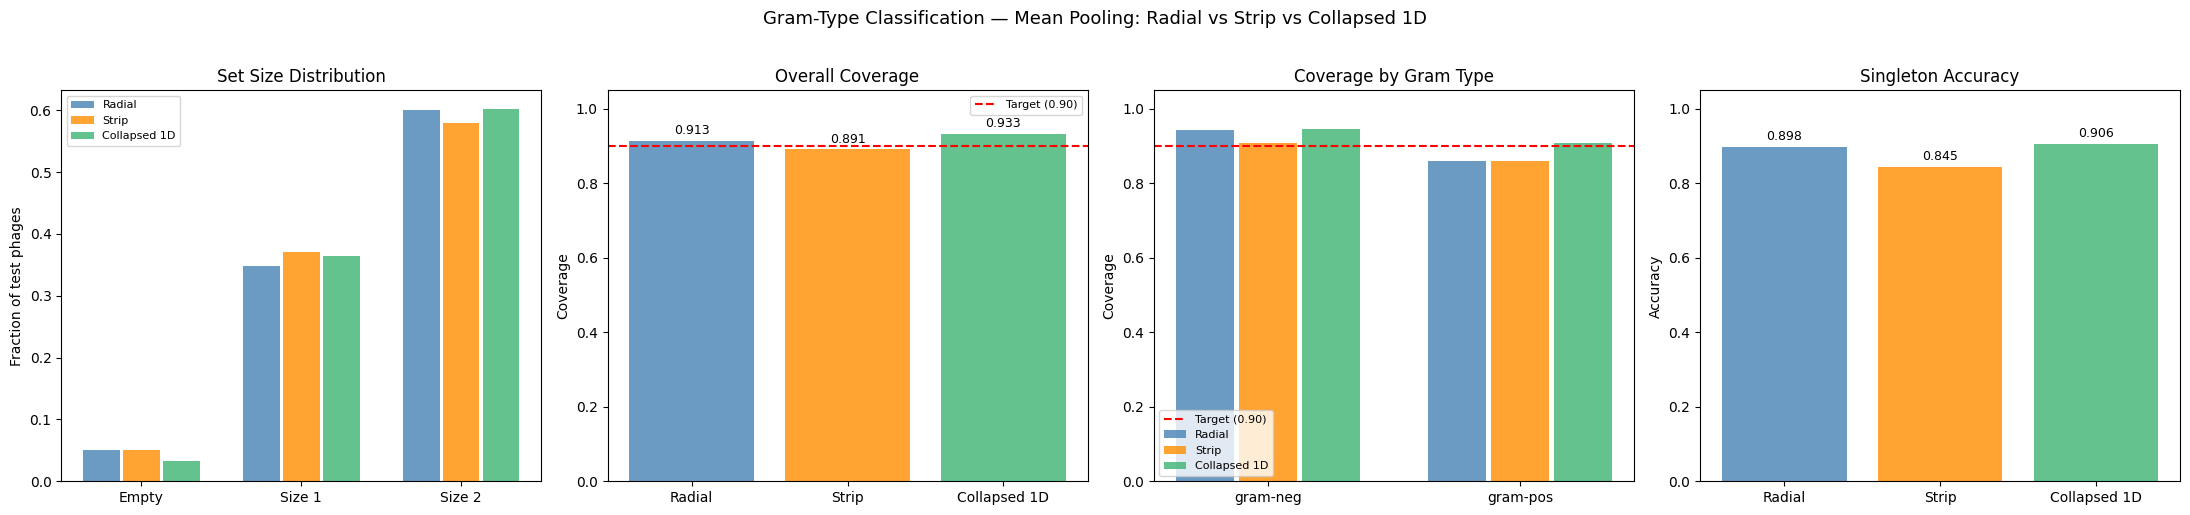

In [26]:
fig, axes = plt.subplots(1, 4, figsize=(22, 5))
methods = ["Radial", "Strip", "Collapsed 1D"]
metrics = [radial_metrics, strip_metrics, collapsed_metrics]
colors  = ["steelblue", "darkorange", "mediumseagreen"]


# Plot 1: Set size distribution
ax = axes[0]
x  = np.array([0, 1, 2])
offsets = [-0.25, 0.0, 0.25]
for name, m, c, offset in zip(methods, metrics, colors, offsets):
    sizes  = m["set_sizes"]
    counts = [sizes.count(s) / len(sizes) for s in [0, 1, 2]]
    ax.bar(x + offset, counts, width=0.23, label=name, color=c, alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(["Empty", "Size 1", "Size 2"])
ax.set_title("Set Size Distribution")
ax.set_ylabel("Fraction of test phages")
ax.legend(fontsize=8)


# Plot 2: Overall coverage
ax   = axes[1]
covs = [m["coverage"] for m in metrics]
bars = ax.bar(methods, covs, color=colors, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_ylim(0, 1.05)
ax.set_title("Overall Coverage")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)
for bar, val in zip(bars, covs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)


# Plot 3: Per-gram-type coverage
ax         = axes[2]
gram_types = ["gram-neg", "gram-pos"]
x          = np.arange(len(gram_types))
offsets    = [-0.25, 0.0, 0.25]
for name, m, c, offset in zip(methods, metrics, colors, offsets):
    vals = [m["per_type_coverage"][gt] for gt in gram_types]
    ax.bar(x + offset, vals, width=0.23, label=name, color=c, alpha=0.8)
ax.axhline(1 - alpha, color="red", linestyle="--", label=f"Target ({1-alpha:.2f})")
ax.set_xticks(x)
ax.set_xticklabels(gram_types)
ax.set_ylim(0, 1.05)
ax.set_title("Coverage by Gram Type")
ax.set_ylabel("Coverage")
ax.legend(fontsize=8)


# Plot 4: Singleton accuracy
ax   = axes[3]
accs = [m["singleton_accuracy"] or 0 for m in metrics]
bars = ax.bar(methods, accs, color=colors, alpha=0.8)
ax.set_ylim(0, 1.05)
ax.set_title("Singleton Accuracy")
ax.set_ylabel("Accuracy")
for bar, val in zip(bars, accs):
    ax.text(bar.get_x() + bar.get_width()/2, val + 0.01, f"{val:.3f}",
            ha="center", va="bottom", fontsize=9)


plt.suptitle("Gram-Type Classification — Mean Pooling: Radial vs Strip vs Collapsed 1D",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


In [27]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.colors import LogNorm

def plot_heatmap(results_A, results_B, name_A, name_B):
    """
    Finalized Heatmap: 
    - (0,0) at bottom-left
    - Log-scaling for colors (better visibility of small numbers)
    - YlGnBu color scheme
    - Actual integer labels on the colorbar
    """
    # Extracting the set sizes (0, 1, or 2)
    sizes_A = [len(r["prediction_set"]) for r in results_A]
    sizes_B = [len(r["prediction_set"]) for r in results_B]
    
    # Create crosstab
    df_comp = pd.DataFrame({name_A: sizes_A, name_B: sizes_B})
    matrix = pd.crosstab(df_comp[name_A], df_comp[name_B])
    
    # To makse sure we get a 3x3 matrix (even if some sizes are missing)
    for i in [0, 1, 2]:
        if i not in matrix.columns: matrix[i] = 0
        if i not in matrix.index: matrix.loc[i] = 0
    matrix = matrix.sort_index(axis=0).sort_index(axis=1)

    # Flipping the matrix vertically so that the size 0 is at the bottom
    matrix_flipped = matrix.iloc[::-1]

    plt.figure(figsize=(8, 6))
    
    # Creating the Heatmap
    # norm=LogNorm() allows us to see small numbers without washing them out
    ax = sns.heatmap(matrix_flipped, annot=True, fmt='d', cmap='YlGnBu', linewidths=1, linecolor='white', norm=LogNorm(), 
                     cbar_kws={'label': 'Count (Log Scale)', 'format': ticker.ScalarFormatter()})

    # 6. Add thick black borders for professional look
    for _, spine in ax.spines.items():
        spine.set_visible(True)
        spine.set_color('black')
        spine.set_linewidth(2)

    plt.title(f"Set Size Analysis: {name_A} vs {name_B}", fontsize=14, pad=20)
    plt.xlabel(f"{name_B} Set Size", fontsize=12)
    plt.ylabel(f"{name_A} Set Size", fontsize=12)
    
    plt.tight_layout()
    plt.show()

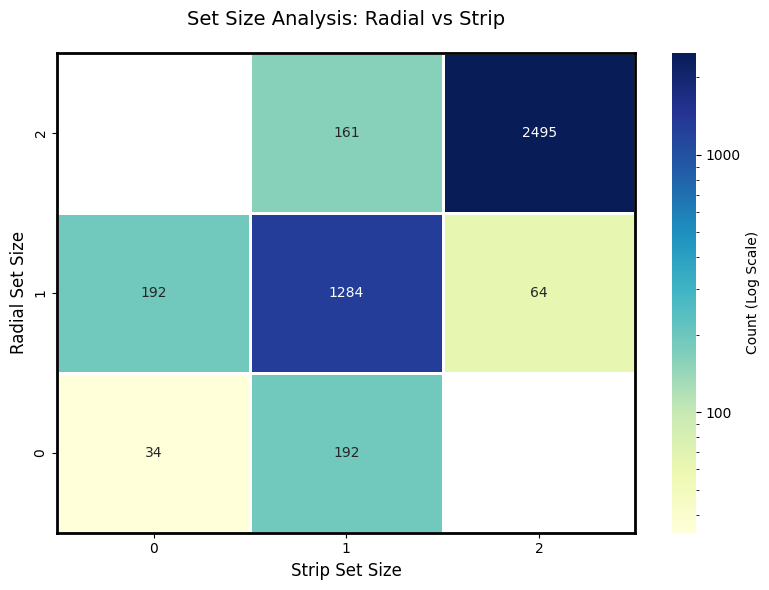

In [28]:
plot_heatmap(radial_results, strip_results, "Radial", "Strip")

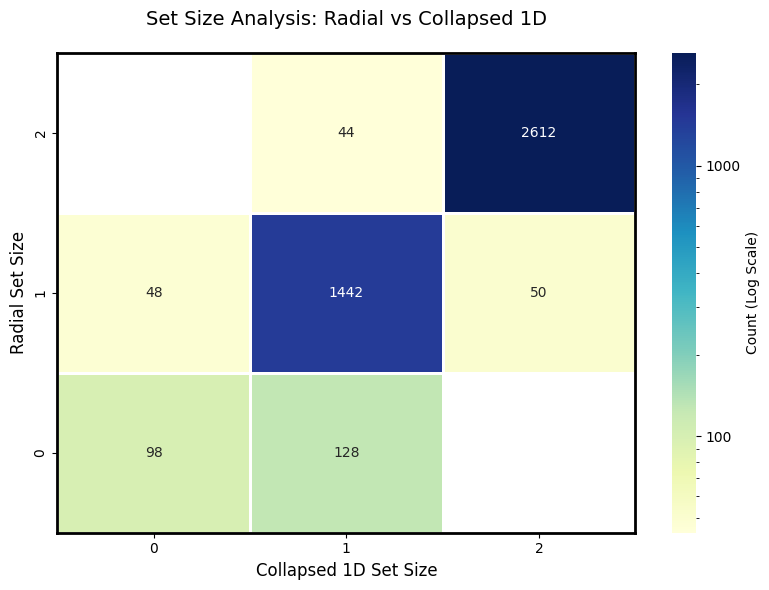

In [29]:
plot_heatmap(radial_results, collapsed_results, "Radial", "Collapsed 1D")

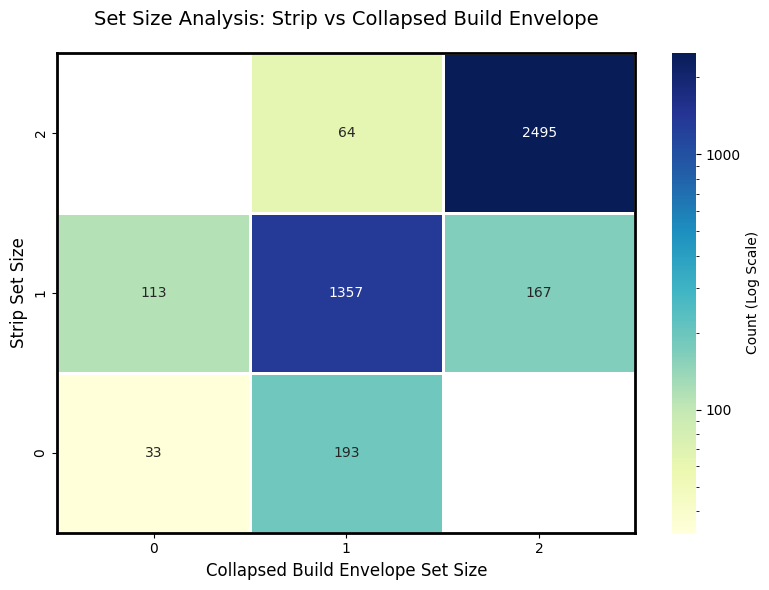

In [30]:
plot_heatmap(strip_results, collapsed_results, "Strip", "Collapsed Build Envelope")

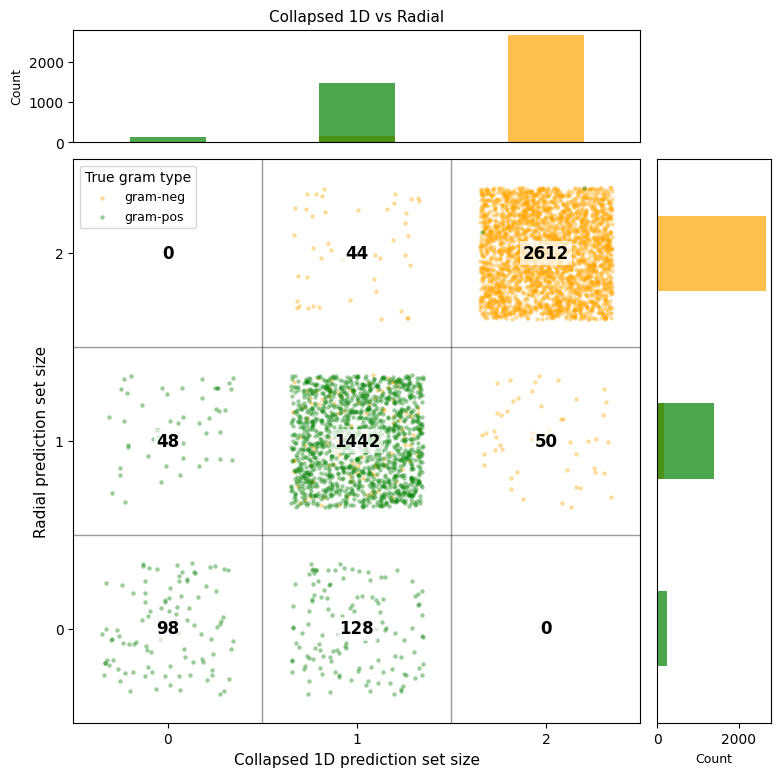

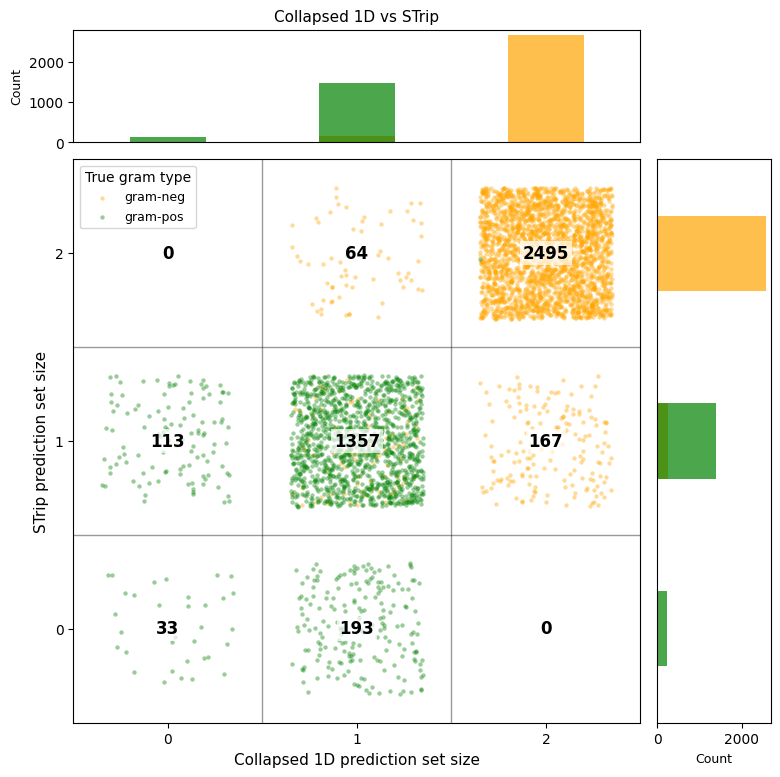

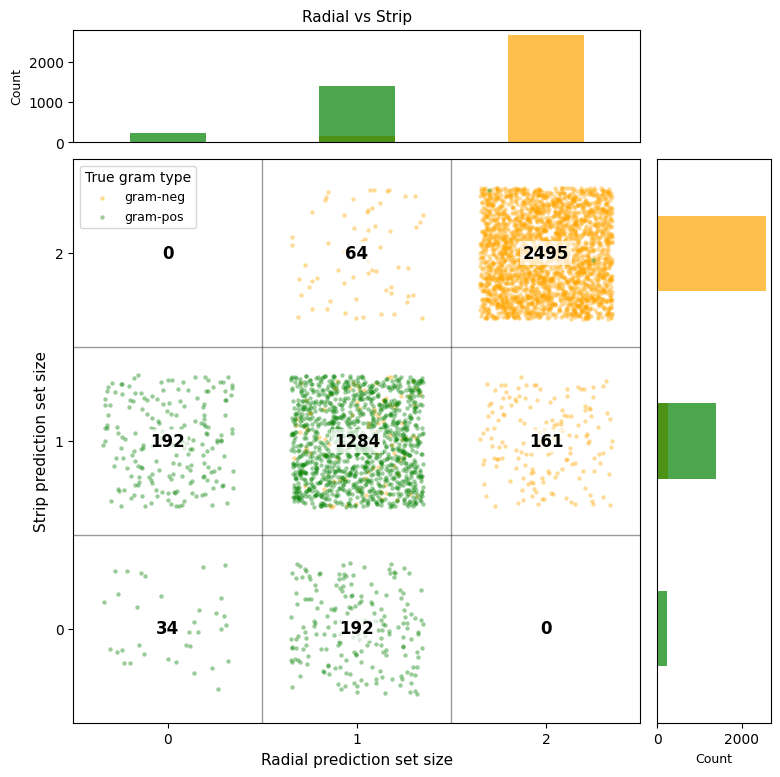

In [35]:
import numpy as np
import matplotlib.pyplot as plt

def plot_method_vs_method_scatter(sizes_x, sizes_y, name_x, name_y):
    """
    Scatter plot with jitter and marginal histograms comparing two K-dim methods.
    sizes_x: array of set sizes for the X-axis method
    sizes_y: array of set sizes for the Y-axis method
    name_x: label for the X-axis (e.g., "Radial")
    name_y: label for the Y-axis (e.g., "Strip")
    """

    gram_colors = {"gram-neg": "orange", "gram-pos": "green"}
    
    fig = plt.figure(figsize=(9, 9))
    gs = fig.add_gridspec(2, 2, width_ratios=[1, 0.2], height_ratios=[0.2, 1], hspace=0.05, wspace=0.05)

    ax_main = fig.add_subplot(gs[1, 0])   # main scatter
    ax_top = fig.add_subplot(gs[0, 0])   # top histogram (X-axis distribution)
    ax_right = fig.add_subplot(gs[1, 1])   # right histogram (Y-axis distribution)

    # Jitter so points spread within each integer cell (0, 1, 2)
    jitter = 0.35
    x_jit = sizes_x + np.random.uniform(-jitter, jitter, len(sizes_x))
    y_jit = sizes_y + np.random.uniform(-jitter, jitter, len(sizes_y))

    # Main scatter — one point per phage, coloured by true gram type
    for lbl, col in gram_colors.items():
        mask = np.array(test_labels) == lbl
        ax_main.scatter(x_jit[mask], y_jit[mask], c=col, s=10, alpha=0.4, linewidths=0, label=lbl)

    # Grid lines to separate the 9 boxes
    for v in [0.5, 1.5]:
        ax_main.axvline(v, color="black", linewidth=1.0, alpha=0.4)
        ax_main.axhline(v, color="black", linewidth=1.0, alpha=0.4)

    # Count annotation in the centre of each box
    for xi in [0, 1, 2]:
        for yi in [0, 1, 2]:
            n_box = ((sizes_x == xi) & (sizes_y == yi)).sum()
            ax_main.text(xi, yi, str(n_box), ha="center", va="center", fontsize=12, fontweight="bold", bbox=dict(facecolor="white", alpha=0.7, edgecolor="none", pad=2))

    # Formatting Main Axis
    ax_main.set_xticks([0, 1, 2])
    ax_main.set_yticks([0, 1, 2])
    ax_main.set_xlim(-0.5, 2.5)
    ax_main.set_ylim(-0.5, 2.5)
    ax_main.set_xlabel(f"{name_x} prediction set size", fontsize=11)
    ax_main.set_ylabel(f"{name_y} prediction set size", fontsize=11)
    ax_main.legend(title="True gram type", fontsize=9, loc="upper left")

    # Top histogram — distribution of Method X
    for lbl, col in gram_colors.items():
        mask = np.array(test_labels) == lbl
        counts = [(sizes_x[mask] == s).sum() for s in [0, 1, 2]]
        ax_top.bar([0, 1, 2], counts, color=col, alpha=0.7, width=0.4, label=lbl)
    ax_top.set_xlim(-0.5, 2.5)
    ax_top.set_xticks([])
    ax_top.set_ylabel("Count", fontsize=9)
    ax_top.set_title(f"{name_x} vs {name_y}", fontsize=11)

    # Right histogram — distribution of Method Y
    for lbl, col in gram_colors.items():
        mask = np.array(test_labels) == lbl
        counts = [(sizes_y[mask] == s).sum() for s in [0, 1, 2]]
        ax_right.barh([0, 1, 2], counts, color=col, alpha=0.7, height=0.4, label=lbl)
    ax_right.set_ylim(-0.5, 2.5)
    ax_right.set_yticks([])
    ax_right.set_xlabel("Count", fontsize=9)

    plt.show()


sizes_collapsed = np.array(collapsed_metrics["set_sizes"])

plot_method_vs_method_scatter(sizes_collapsed, kdim_set_sizes_radial, "Collapsed 1D", "Radial")

plot_method_vs_method_scatter(sizes_collapsed, kdim_set_sizes_strip, "Collapsed 1D", "STrip")

plot_method_vs_method_scatter(kdim_set_sizes_radial, kdim_set_sizes_strip, "Radial", "Strip")